In [1]:
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
sys.path.append('..')

import utilities.functions as functions
import utilities.descritiva as descritiva

from utilities.descritiva import  (
    matriz_migracao,
    cria_base_decil_wide
)

from utilities.functions import (
    summary,
    gerar_resumo_decis,
    resumo_coorte_ativa,
    process_orders_pandas

)
from pathlib import Path
BASE_PATH = Path("/Users/maceli/ifood_cs/dados") 


In [8]:
df_pub_u = pd.read_parquet(BASE_PATH / "silver" / "df_p_2.parquet")

In [15]:
df_pub_u = pd.read_parquet(BASE_PATH / "gold" / "df_pub_un.parquet")
df_pub_u
#df_pub_u=process_orders_pandas(df_pub_u)

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum
0,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,12,1,2,88.8,88.80,1
1,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,1,1,2,88.8,88.80,1
2,0001004b6873a53fef60d11f4d2e4435ea27bed7e5fc38...,target,1,1,1,30.9,30.90,1
3,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,12,1,2,47.6,47.60,1
4,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,1,1,2,47.6,47.60,1
...,...,...,...,...,...,...,...,...
168642,fffebe8f36625fbc708361eeaa301fee40b849e2bf4666...,target,1,2,4,96.3,48.15,2
168643,fffef917711775d1ba63ec1d8054f9705177edef950699...,control,12,1,2,23.8,23.80,1
168644,fffef917711775d1ba63ec1d8054f9705177edef950699...,control,1,1,2,23.8,23.80,1
168645,ffff43a3295b205e9024717bd803b218f49aa87c8e2b90...,control,12,1,2,59.0,59.00,1


In [16]:
#f_pub_u = df_pub_u[["customer_id","is_target", "order_created_month", "num_pedidos_mes", "num_pedidos_hist",'total_amount_mes','ticket_medio']].drop_duplicates().reset_index(drop=True)
df_pub_u['pedidos_sum'] = np.where(
        df_pub_u['num_pedidos_mes'] > 10, '10+',
        df_pub_u['num_pedidos_mes'].astype(str)
    )
df_pub_u.head()

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum
0,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,12,1,2,88.8,88.8,1
1,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,1,1,2,88.8,88.8,1
2,0001004b6873a53fef60d11f4d2e4435ea27bed7e5fc38...,target,1,1,1,30.9,30.9,1
3,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,12,1,2,47.6,47.6,1
4,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,1,1,2,47.6,47.6,1


In [17]:
df_pub_u.head()

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum
0,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,12,1,2,88.8,88.8,1
1,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,1,1,2,88.8,88.8,1
2,0001004b6873a53fef60d11f4d2e4435ea27bed7e5fc38...,target,1,1,1,30.9,30.9,1
3,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,12,1,2,47.6,47.6,1
4,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,1,1,2,47.6,47.6,1


Sumarizacao na visao cliente - mes

In [18]:
summary(df_pub_u)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,168647,99964,000032b594523c3f8868edee4f1577b157e115cd01ab31...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
is_target,168647,2,target,94075,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_created_month,168647.0,NaN,NaN,NaN,5.479848,5.404578,1.0,1.0,1.0,12.0,12.0
num_pedidos_mes,168647.0,NaN,NaN,NaN,2.687412,3.220458,1.0,1.0,2.0,3.0,105.0
num_pedidos_hist,168647.0,NaN,NaN,NaN,5.102795,5.966617,1.0,2.0,3.0,6.0,137.0
total_amount_mes,168647.0,NaN,NaN,NaN,128.545565,208.419399,0.0,39.0,68.9,143.0,37302.6
ticket_medio,168647.0,NaN,NaN,NaN,47.755141,39.46107,0.0,29.25,40.98,56.8,9325.65
pedidos_sum,168647,11,1,83719,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Clientes mes x target

 Matriz de migracao - cliente

In [19]:
matriz_migracao(df_pub_u,mes_0=12,mes_1=1)

,mes_12,mes_1,is_target,total_clientes
0,0,1,control,14616
1,0,1,target,16665
2,1,1,control,29978
3,1,1,target,38705


Dado o montante de clientes novos em janeiro a analise sera feita basead em cliente ambos os meses e cliente somente em janeiro

In [20]:
id_both_monht=df_pub_u[df_pub_u['order_created_month']==12]['customer_id'].unique()
publico_janeiro_dezembro = df_pub_u[df_pub_u['customer_id'].isin(id_both_monht)].reset_index(drop=True)
publico_janeiro = df_pub_u[~df_pub_u['customer_id'].isin(id_both_monht)].reset_index(drop=True)

In [21]:
publico_janeiro_dezembro.to_parquet(BASE_PATH / "gold" / "publico_janeiro_dezembro.parquet", index=False)

Pedidos por mes - target

In [22]:
pedidos_total = (
    publico_janeiro_dezembro.groupby(['is_target','order_created_month'])['num_pedidos_mes']
      .sum()
      .reset_index(name='numero_de_pedidos_total')
)

pedidos_total['pct_mes'] = pedidos_total.groupby('order_created_month')['numero_de_pedidos_total'] \
                 .transform(lambda x: x / x.sum() * 100).round(2)

pedidos_total


,is_target,order_created_month,numero_de_pedidos_total,pct_mes
0,control,1,105103,41.23
1,control,12,64031,42.00
2,target,1,149791,58.77
3,target,12,88422,58.00


Distruibuicao do total amount por mes

In [23]:
df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target'])['total_amount_mes'].agg(
    Média=('mean'),
    Mediana=('median'),
    Mínimo=('min'),
    Máximo=('max'),
    Desvio_Padrão=('std')
).round(2)
df_stats_mes

Média  Mediana  Mínimo   Máximo  Desvio_Padrão
order_created_month is_target                                                 
1                   control    167.58     89.4    2.50  4429.20         234.60
                    target     186.12    104.6    2.75  5182.00         257.92
12                  control    101.60     59.9    2.50  4281.85         129.82
                    target     108.95     65.1    0.00  5044.94         139.39

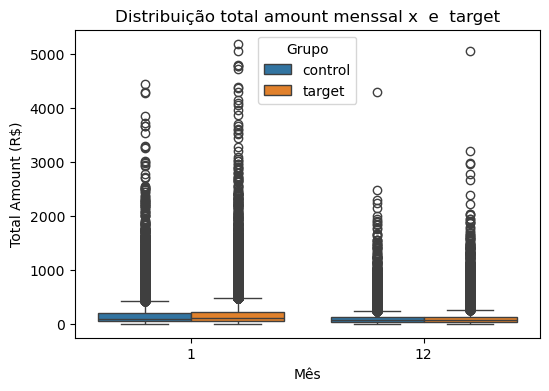

In [24]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    data=publico_janeiro_dezembro,
    y='total_amount_mes',
    x='order_created_month',  
    hue='is_target'          
)
plt.title('Distribuição total amount menssal x  e  target')
plt.ylabel('Total Amount (R$)')
plt.xlabel('Mês')
plt.legend(title='Grupo')
plt.show()

Observa-se grande numero de outliers, verificar a distribuicao removendo outliers.

In [25]:
print(publico_janeiro_dezembro[publico_janeiro_dezembro['order_created_month']==12]['total_amount_mes'].describe().round(2))
print(publico_janeiro_dezembro[publico_janeiro_dezembro['order_created_month']==1]['total_amount_mes'].describe().round(2))



count    68683.00
mean       105.74
std        135.34
min          0.00
25%         37.00
50%         62.80
75%        122.80
max       5044.94
Name: total_amount_mes, dtype: float64
count    68683.00
mean       178.03
std        248.18
min          2.50
25%         47.90
50%         97.80
75%        209.60
max       5182.00
Name: total_amount_mes, dtype: float64


<Axes: >

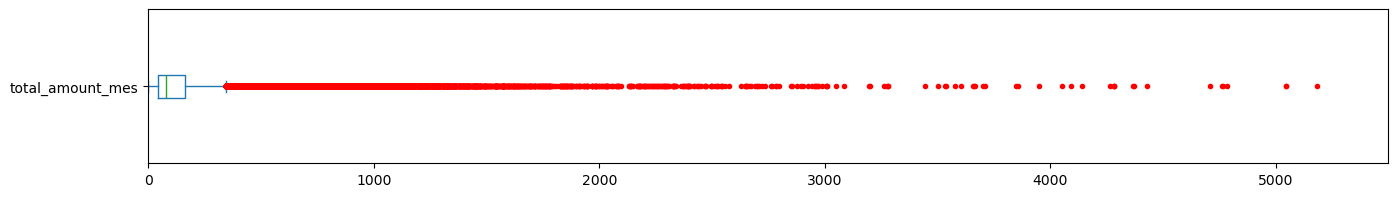

In [26]:
red_square = dict(markerfacecolor='r', markeredgecolor='r', marker='.')
publico_janeiro_dezembro['total_amount_mes'].plot(kind='box', xlim=(0, 5500), vert=False, flierprops=red_square, figsize=(16,2))

In [27]:
p75=np.nanpercentile(publico_janeiro_dezembro.loc[publico_janeiro_dezembro['order_created_month'] == 12, 'total_amount_mes' ],75)
p25=np.nanpercentile(publico_janeiro_dezembro.loc[publico_janeiro_dezembro['order_created_month'] == 12, 'total_amount_mes' ],25)

In [28]:
distance = 1.5 * (p75 - p25)
lim_sup= p75+distance
lim_inf = p25-distance
print(lim_sup)


251.5


Marcacao de outliers - amount na base historica e griando uma base somente com outliers

In [29]:
publico_janeiro_dezembro['outlier'] = publico_janeiro_dezembro['total_amount_mes'] > lim_sup
df_out= publico_janeiro_dezembro[publico_janeiro_dezembro['total_amount_mes'] > lim_sup]

In [30]:
total_amount = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target']).agg(
    total_amount=('total_amount_mes', 'sum'),
    total_pedidos=('num_pedidos_mes', 'sum')
).round(2)

total_amount_out = df_out.groupby(['order_created_month', 'is_target']).agg(
    total_amount=('total_amount_mes', 'sum'),
    total_pedidos=('num_pedidos_mes', 'sum')
).round(2)
#total_amount_out
#total_amount

merged = (
    total_amount
    .merge(total_amount_out, on=['order_created_month', 'is_target'], how='left', suffixes=('_all', '_out'))
    .assign(
        pct_amount_out=lambda x: (x['total_amount_out'] / x['total_amount_all']).round(4),
        pct_pedidos_out=lambda x: (x['total_pedidos_out'] / x['total_pedidos_all']).round(4)
    )
)
merged

total_amount_all  total_pedidos_all  \
order_created_month is_target                                        
1                   control          5023648.81             105103   
                    target           7203827.72             149791   
12                  control          3045652.84              64031   
                    target           4217077.16              88422   

                               total_amount_out  total_pedidos_out  \
order_created_month is_target                                        
1                   control          2907203.60              52218   
                    target           4329206.14              77301   
12                  control          1016012.01              15997   
                    target           1486918.25              23504   

                               pct_amount_out  pct_pedidos_out  
order_created_month is_target                                   
1                   control            0.5787           0.4968  
                    target             0.6010           0.5161  
12                  control            0.3336           0.2498  
                    target             0.3526           0.2658

Migracao based in marcacao de outlier

In [31]:
matriz_migracao(publico_janeiro_dezembro, 12, 1, group_by_extra='outlier')

,mes_12,mes_1,is_target,outlier,total_clientes
0,0,1,control,True,3268
1,0,1,target,True,4835
2,1,0,control,False,3268
3,1,0,target,False,4835
4,1,1,control,False,24376
5,1,1,control,True,2334
6,1,1,target,False,30495
7,1,1,target,True,3375


Entender quem sao esse clientes outliers

In [32]:
decil_dict = cria_base_decil_wide(publico_janeiro_dezembro, mes_0=12)

# 2) Aplicar
publico_janeiro_dezembro['decil'] = publico_janeiro_dezembro['total_amount_mes'].apply(
    lambda x: max([decil for decil, (min_val, max_val) in decil_dict.items() if x >= min_val])
)

In [35]:
clientes_mes = (
    publico_janeiro_dezembro.groupby(['order_created_month','decil'], dropna=False)
              ['customer_id']
              .nunique()
              .reset_index(name='numero_clientes_distintos')
)
clientes_mes

,order_created_month,decil,numero_clientes_distintos
0,1,1,4577
1,1,2,4573
2,1,3,4745
3,1,4,4813
4,1,5,5201
5,1,6,5651
6,1,7,6544
7,1,8,7548
8,1,9,9283
9,1,10,15748


In [ ]:
publico_janeiro_dezembro

In [38]:
def calcular_stats(group):
    media = group['total_amount_mes'].mean()
    std = group['total_amount_mes'].std()
    return pd.Series({
        'Total_Clientes': group['customer_id'].nunique(),
        'Total_Orders': group['num_pedidos_mes'].sum(),  # ou count() dependendo da sua estrutura
        'Média_Amount': media,
        'Mediana_Amount': group['total_amount_mes'].median(),
        'Mínimo_Amount': group['total_amount_mes'].min(),
        'Máximo_Amount': group['total_amount_mes'].max(),
        'Desvio_Padrão_Amount': std,
        'CV_Amount': (std / media * 100) if media != 0 else np.nan
    })

df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target','decil']).apply(calcular_stats).round(2)
df_stats_mes.head()

/var/folders/s5/dkrzm08d6wl79n0by4mcn72m0000gn/T/ipykernel_34738/3857564857.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'is_target','decil']).apply(calcular_stats).round(2)


Total_Clientes  Total_Orders  \
order_created_month is_target decil                                 
1                   control   1              2293.0        2331.0   
                              2              2280.0        2420.0   
                              3              2285.0        2605.0   
                              4              2237.0        2741.0   
                              5              2357.0        3393.0   

                                     Média_Amount  Mediana_Amount  \
order_created_month is_target decil                                 
1                   control   1             18.22           18.90   
                              2             28.73           28.98   
                              3             36.97           37.00   
                              4             46.08           46.00   
                              5             56.39           56.09   

                                     Mínimo_Amount  Máximo_Amount  \
order_created_month is_target decil                                 
1                   control   1                2.5          24.30   
                              2               24.4          32.88   
                              3               32.9          41.37   
                              4               41.4          50.49   
                              5               50.5          62.79   

                                     Desvio_Padrão_Amount  CV_Amount  
order_created_month is_target decil                                   
1                   control   1                      4.18      22.93  
                              2                      2.47       8.60  
                              3                      2.47       6.68  
                              4                      2.69       5.84  
                              5                      3.43       6.08

In [39]:
publico_janeiro_dezembro.to_parquet(BASE_PATH / "gold" / "publico_janeiro_dezembro.parquet", index=False)

In [ ]:
os.makedirs('../../Resultados', exist_ok=True)

#decil_summary.to_csv('../../Resultados/decil_summary.csv', index=False)



Numero de pedidos em Janeiro e Dezembro para o quem esteve em ambos meses

In [42]:

df_stats_mes = publico_janeiro_dezembro.groupby(['order_created_month', 'pedidos_sum']).agg(
    total_clientes=('customer_id', 'nunique')
).round(2)

df_stats_mes['pct_mes'] = df_stats_mes.groupby('order_created_month')['total_clientes'] \
                 .transform(lambda x: x / x.sum() * 100).round(2)


df_stats_hist = publico_janeiro_dezembro.groupby(['pedidos_sum']).agg(
    total_clientes=('customer_id', 'nunique')
).round(2)

df_stats_hist['pct_total'] = (df_stats_hist['total_clientes'] / df_stats_hist['total_clientes'].sum() * 100).round(2)
df_stats_hist

,total_clientes,pct_total
pedidos_sum,,
1,37161,36.32
10,1213,1.19
10+,4245,4.15
2,20875,20.40
3,13173,12.88
4,8719,8.52
5,5918,5.78
6,4174,4.08
7,3001,2.93


In [ ]:
publico_janeiro_dezembro.head()

In [ ]:
df_stats_mes

In [ ]:
publico_janeiro_dezembro.head(2)

KeyError: 'order_created_month'

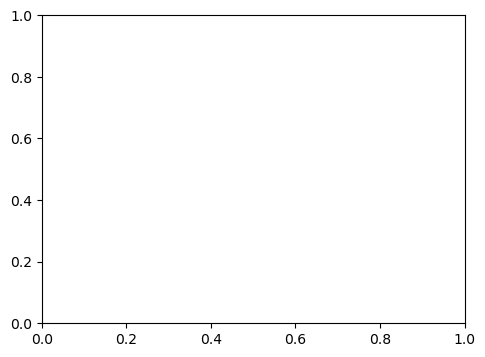

In [43]:
# Gráfico 1 - Total de clientes por mês e grupo
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)  # 1 linha, 2 colunas, posição 1
sns.barplot(
    data=df_stats_mes[df_stats_mes['order_created_month']==12],
    x='pedidos_sum',
    y='ticket_medio',
    hue='is_target'
)
plt.title('Número de Clientes por Mês')
plt.ylabel('Total de Clientes')
plt.xlabel('Mês')



In [ ]:
publico_janeiro_dezembro.head()

In [ ]:
publico_janeiro_dezembro

In [ ]:
publico_janeiro_dezembro.head()

In [44]:
publico_janeiro_dezembro[
        (publico_janeiro_dezembro['num_pedidos_mes'] < 11) & 
        (publico_janeiro_dezembro['outlier'] == False)]

,customer_id,is_target,order_created_month,num_pedidos_mes,num_pedidos_hist,total_amount_mes,ticket_medio,pedidos_sum,outlier,decil
0,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,12,1,2,88.8,88.80,1,False,7
1,000032b594523c3f8868edee4f1577b157e115cd01ab31...,control,1,1,2,88.8,88.80,1,False,7
2,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,12,1,2,47.6,47.60,1,False,4
3,000200d3759a5b4d0083d212773ae6e304cbe91ffddede...,target,1,1,2,47.6,47.60,1,False,4
4,00021cd56b6d6c980c3b48ca0fdf8c53cf3fea776d74ab...,target,12,2,5,31.9,15.95,2,False,2
...,...,...,...,...,...,...,...,...,...,...
137361,fffebe8f36625fbc708361eeaa301fee40b849e2bf4666...,target,1,2,4,96.3,48.15,2,False,7
137362,fffef917711775d1ba63ec1d8054f9705177edef950699...,control,12,1,2,23.8,23.80,1,False,1
137363,fffef917711775d1ba63ec1d8054f9705177edef950699...,control,1,1,2,23.8,23.80,1,False,1
137364,ffff43a3295b205e9024717bd803b218f49aa87c8e2b90...,control,12,1,2,59.0,59.00,1,False,5


In [45]:
total_amount = (
    publico_janeiro_dezembro[
        (publico_janeiro_dezembro['num_pedidos_mes'] < 11) & 
        (publico_janeiro_dezembro['outlier'] == False)
    ]
    .groupby(['order_created_month', 'is_target'])
    .agg(
        total_amount=('total_amount_mes', 'sum'),
        total_pedidos=('num_pedidos_mes', 'sum')
    )
    .round(2)
)
total_amount

total_amount  total_pedidos
order_created_month is_target                             
1                   control      2106535.21          52324
                    target       2862023.68          71725
12                  control      2024852.34          47766
                    target       2724828.86          64626

In [46]:
# CORREÇÃO: Filtro com parênteses corretos
total_amount_f= (
    publico_janeiro_dezembro[
        (publico_janeiro_dezembro['num_pedidos_mes'] < 11) & 
        (publico_janeiro_dezembro['outlier'] == False)
    ]
    .groupby(['order_created_month', 'is_target'])
    .agg(
        total_amount=('total_amount_mes', 'sum'),
        total_pedidos=('num_pedidos_mes', 'sum'),
        total_customer=('customer_id', 'nunique'),

    )
    .round(2)
)

total_amount_total = (
    publico_janeiro_dezembro.groupby(['order_created_month', 'is_target'])
    .agg(
        total_amount=('total_amount_mes', 'sum'),
        total_pedidos=('num_pedidos_mes', 'sum'),
        total_customer=('customer_id', 'nunique'),
    )
    .round(2)
)

merged = (
    total_amount_total
    .merge(total_amount_f, on=['order_created_month', 'is_target'], how='left', suffixes=('_all', '_out'))
    .assign(
        pct_amount_out=lambda x: (x['total_amount_out'] / x['total_amount_all']).round(4),
        pct_pedidos_out=lambda x: (x['total_pedidos_out'] / x['total_pedidos_all']).round(4),
        pct_c=lambda x: (x['total_customer_out'] / x['total_customer_all']).round(4)
    )
)

merged

total_amount_all  total_pedidos_all  \
order_created_month is_target                                        
1                   control          5023648.81             105103   
                    target           7203827.72             149791   
12                  control          3045652.84              64031   
                    target           4217077.16              88422   

                               total_customer_all  total_amount_out  \
order_created_month is_target                                         
1                   control                 29978        2106535.21   
                    target                  38705        2862023.68   
12                  control                 29978        2024852.34   
                    target                  38705        2724828.86   

                               total_pedidos_out  total_customer_out  \
order_created_month is_target                                          
1                   control                52324               24329   
                    target                 71725               30433   
12                  control                47766               27622   
                    target                 64626               35306   

                               pct_amount_out  pct_pedidos_out   pct_c  
order_created_month is_target                                           
1                   control            0.4193           0.4978  0.8116  
                    target             0.3973           0.4788  0.7863  
12                  control            0.6648           0.7460  0.9214  
                    target             0.6461           0.7309  0.9122

In [47]:
# CORREÇÃO: Filtro com parênteses corretos
total_amount_f= (
    publico_janeiro_dezembro[
        (publico_janeiro_dezembro['num_pedidos_mes'] >= 11) #& 
        #(publico_janeiro_dezembro['outlier'] == False)
    ]
    .groupby(['order_created_month', 'is_target'])
    .agg(
        total_amount=('total_amount_mes', 'sum'),
        total_pedidos=('num_pedidos_mes', 'sum'),
        total_customer=('customer_id', 'nunique'),

    )
    .round(2)
)

total_amount_total = (
    publico_janeiro_dezembro.groupby(['order_created_month', 'is_target'])
    .agg(
        total_amount=('total_amount_mes', 'sum'),
        total_pedidos=('num_pedidos_mes', 'sum'),
        total_customer=('customer_id', 'nunique'),
    )
    .round(2)
)

merged = (
    total_amount_total
    .merge(total_amount_f, on=['order_created_month', 'is_target'], how='left', suffixes=('_all', '_out'))
    .assign(
        pct_amount_out=lambda x: (x['total_amount_out'] / x['total_amount_all']).round(4),
        pct_pedidos_out=lambda x: (x['total_pedidos_out'] / x['total_pedidos_all']).round(4),
        pct_c=lambda x: (x['total_customer_out'] / x['total_customer_all']).round(4)
    )
)

merged

total_amount_all  total_pedidos_all  \
order_created_month is_target                                        
1                   control          5023648.81             105103   
                    target           7203827.72             149791   
12                  control          3045652.84              64031   
                    target           4217077.16              88422   

                               total_customer_all  total_amount_out  \
order_created_month is_target                                         
1                   control                 29978        1314061.25   
                    target                  38705        2021339.36   
12                  control                 29978         242084.02   
                    target                  38705         366450.37   

                               total_pedidos_out  total_customer_out  \
order_created_month is_target                                          
1                   control                27699                1711   
                    target                 41743                2534   
12                  control                 5042                 354   
                    target                  7743                 532   

                               pct_amount_out  pct_pedidos_out   pct_c  
order_created_month is_target                                           
1                   control            0.2616           0.2635  0.0571  
                    target             0.2806           0.2787  0.0655  
12                  control            0.0795           0.0787  0.0118  
                    target             0.0869           0.0876  0.0137

In [48]:

pedidos_hist=resumo_coorte_ativa(publico_janeiro_dezembro,mes_coorte_inicio=12,mes_coorte_fim=1)
pedidos_hist

,is_target,Total_Pedidos_Mes_1,Total_Pedidos_Mes_12,Total_Clientes
0,control,1,1,11997
1,control,2,1,2814
2,control,2,2,2484
3,control,3,1,1244
4,control,3,2,1149
...,...,...,...,...
744,target,61,35,1
745,target,63,26,1
746,target,64,27,1
747,target,72,30,1


In [ ]:
import os

if os.path.exists('../Resultados'):
    pedidos_hist.to_csv('../Resultados/pedidos_hist.csv', index=False)
else:
    # Criar pasta ou salvar em outro lugar
    os.makedirs('../Resultados', exist_ok=True)
    pedidos_hist.to_csv('../Resultados/pedidos_hist.csv', index=False)
    print("Pasta criada e arquivo salvo!")

In [ ]:
pedidos_hist.to_csv('../Resultados/pedidos_hist.csv', index=False)
#df_stats_hist
#df_stats_mes

In [ ]:
with pd.ExcelWriter('../../Resultados/analise_pedidos.xlsx') as writer:
    pedidos_hist.to_excel(writer, sheet_name='Pedidos_Hist', index=False)
    df_stats_hist.to_excel(writer, sheet_name='Stats_Hist', index=True)
    df_stats_mes.to_excel(writer, sheet_name='Stats_Mes', index=True)